# IITM Reinforcement Learning Course Project
## Industrial Inventory Control using Reinforcement Learning

This notebook demonstrates:

1. generate the assigned parameter variant from the roll number : DA25M502;
2. create and inspect the Gymnasium environment;
3. convert between order quantities and the internal `MultiDiscrete` action;
4. interact with the environment;
5. organise experiments for all eleven distinct RL techniques and select top 5 perfoming techniques.


## 1. Setup

Kept the `industrial_inventory_env` folder in the same project directory as this notebook. Installed the approved packages using:

```bash
pip install -r requirements.txt
```

In [8]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from industrial_inventory_env import (
    IndustrialInventoryEnv,
    generate_student_config,
    public_config_summary,
)

import random
import collections
from collections import defaultdict
from pathlib import Path
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import torch.multiprocessing as mp

np.set_printoptions(suppress=True)
print("Imports completed.")

Imports completed.


## 2. Generate the assigned parameter variant

Entered the official roll number DA25M502 below. The same normalized roll number always generates the same variant for this project version.

In [11]:
ROLL_NUMBER = "DA25M502"  # Replace this text once.

student_config = generate_student_config(ROLL_NUMBER)
config_summary = public_config_summary(student_config)

print("Assigned configuration generated successfully.")
for key, value in config_summary.items():
    print(f"{key}: {value}")

Assigned configuration generated successfully.
project_version: IITM-6002W-RL-Inventory-2026-v1
roll_number: DA25M502
variant_id: V034
config_fingerprint: c24e5a71fa476b69
demand_multiplier_profile: [1.0, 1.15, 0.85]
initial_inventory_profile: [110, 100, 90]
lead_time_delay_profile: [0.1, 0.0, 0.05]


Recorded the generated `variant_id` and `config_fingerprint` in the notebook and briefed report.

## 3. Create the environment

`scenario_mode="random"` permits stationary episodes and combinations of the declared seasonal, trend and temporary-shock characteristics. Episode parameters are generated deterministically from the reset seed.

In [12]:
env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

observation, info = env.reset(seed=2026)

print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Variant:", info["variant_id"])
print("Scenario components:", info["episode_parameters"]["scenario_components"])
print("Episode demand multipliers:", info["episode_parameters"]["demand_multipliers"])
print("Episode initial inventory:", info["episode_parameters"]["initial_inventory"])
print("Episode delay probabilities:", info["episode_parameters"]["delay_probabilities"])

Action space: MultiDiscrete([11 11 11])
Observation space: Dict('arrival_pipeline': Box(0, 10000, (3, 4), int32), 'capacity_utilisation': Box(0.0, 1.0, (1,), float32), 'day': Box(0, 50, (1,), int32), 'demand_history': Box(0, 10000, (7, 3), int32), 'inventory': Box(0, 1000, (3,), int32))
Variant: V034
Scenario components: ['seasonal', 'trend']
Episode demand multipliers: [1.05, 1.0999999999999999, 0.85]
Episode initial inventory: [110, 100, 90]
Episode delay probabilities: [0.08, 0.0, 0.05]


In [13]:
for key, value in observation.items():
    print(f"{key:22s} shape={value.shape}, dtype={value.dtype}")
    print(value)
    print()

inventory              shape=(3,), dtype=int32
[110 100  90]

arrival_pipeline       shape=(3, 4), dtype=int32
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

demand_history         shape=(7, 3), dtype=int32
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

day                    shape=(1,), dtype=int32
[0]

capacity_utilisation   shape=(1,), dtype=float32
[0.655]



## 4. Action representation

The environment accepts internal indices `[0, ..., 10]` for each product. The leaderboard `run_policy(observation)` function must return actual quantities from `{0, 10, ..., 100}`. Used the supplied conversion utility during local interaction.

In [14]:
order_quantities = [40, 20, 0]
action_indices = env.quantities_to_action_indices(order_quantities)

print("Actual order quantities:", order_quantities)
print("Internal action indices:", action_indices.tolist())
print("Converted back:", env.action_indices_to_quantities(action_indices).tolist())

Actual order quantities: [40, 20, 0]
Internal action indices: [4, 2, 0]
Converted back: [40, 20, 0]


## 5. Build the local evaluation loop

A function that evaluates a supplied policy across multiple disclosed validation seeds and multiple declared scenario families. At minimum, record:

- average and standard deviation of total episode cost;
- holding, stockout, ordering and discarding costs;
- service level or unfulfilled demand;
- computational time;
- the seeds and scenario modes used.



In [19]:
# TODO: Implement your own evaluation function.
# Suggested signature:
#
# def evaluate_policy(policy, seeds, scenario_modes):
#     ...
#     return results_dataframe
#
# The function should call policy(observation), convert quantities to action indices,
# execute complete 50-day episodes and aggregate unscaled episode cost.

def evaluate_policy(
    policy_func,
    seeds: list[int] | None = None,
    scenario_modes: list[str] | None = None,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Evaluates a policy across multiple seeds and scenario families.
    Returns a pandas DataFrame containing detailed cost metrics per episode.
    """
    if seeds is None:
        seeds = [101, 202, 303, 404, 505]
    if scenario_modes is None:
        scenario_modes = ["stationary", "seasonal", "trend", "shock", "mixed"]

    records = []

    for mode in scenario_modes:
        eval_env = IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode=mode,
            domain_randomization=True,
        )

        for seed in seeds:
            obs, info = eval_env.reset(seed=seed)
            done = False
            unfulfilled_total = 0

            while not done:
                # 1. Get raw quantities from policy [q1, q2, q3]
                quantities = policy_func(obs)
                
                # 2. Convert raw quantities to environment MultiDiscrete indices
                action_indices = eval_env.quantities_to_action_indices(quantities)
                
                # 3. Step the environment
                obs, reward, terminated, truncated, step_info = eval_env.step(action_indices)
                unfulfilled_total += step_info["unfulfilled_demand"].sum()
                done = terminated or truncated

            # Record final episode metrics
            costs = step_info["costs"]
            records.append({
                "scenario_mode": mode,
                "seed": seed,
                "total_cost": costs["episode_total"],
                "holding_cost": costs["holding"],
                "stockout_cost": costs["stockout"],
                "ordering_cost": costs["ordering"],
                "discard_cost": costs["discarding"],
                "total_unfulfilled": int(unfulfilled_total),
            })

    results_df = pd.DataFrame(records)

    if verbose:
        summary = results_df.groupby("scenario_mode")["total_cost"].agg(["mean", "std"])
        print("\n--- Evaluation Summary by Scenario ---")
        print(summary.round(2))
        print(f"\nOverall Mean Episode Cost: {results_df['total_cost'].mean():.2f} (± {results_df['total_cost'].std():.2f})\n")

    return results_df

## 6. Tabular Q-Learning

In [20]:
def get_tabular_state(obs: dict) -> tuple:
    """Discretizes total inventory position for each of the 3 products into bins."""
    inv = np.asarray(obs["inventory"], dtype=float)
    pipeline = np.asarray(obs["arrival_pipeline"], dtype=float)
    # Inventory position = on-hand + pending arrivals
    inv_pos = inv + pipeline.sum(axis=1)

    # Bin each product's inventory position (0 to 200+ units into 8 bins)
    bins = [0, 40, 70, 100, 130, 160, 200]
    b1 = int(np.digitize(inv_pos[0], bins))
    b2 = int(np.digitize(inv_pos[1], bins))
    b3 = int(np.digitize(inv_pos[2], bins))

    return (b1, b2, b3)

# 11 possible actions per product -> [0, 10, ..., 100]
# To keep tabular action space manageable, use standard reorder points:
ALLOWED_ACTIONS = [
    [0, 0, 0],
    [30, 20, 30], 
    [40, 30, 40],
    [50, 40, 50],
    [20, 20, 20],
    [60, 50, 60],
]

Q_table = defaultdict(lambda: np.zeros(len(ALLOWED_ACTIONS)))

# Hyperparameters
num_episodes = 1500
alpha = 0.1  # learning rate
gamma = 0.95  # discount factor
epsilon = 1.0  # initial exploration
epsilon_min = 0.05
epsilon_decay = 0.997

train_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

print("Starting Tabular Q-Learning Training...")
for episode in range(1, num_episodes + 1):
    obs, info = train_env.reset()
    state = get_tabular_state(obs)
    done = False

    while not done:
        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action_idx = random.randint(0, len(ALLOWED_ACTIONS) - 1)
        else:
            action_idx = int(np.argmax(Q_table[state]))

        order_quantities = ALLOWED_ACTIONS[action_idx]
        env_action = train_env.quantities_to_action_indices(order_quantities)

        next_obs, reward, terminated, truncated, _ = train_env.step(env_action)
        next_state = get_tabular_state(next_obs)
        done = terminated or truncated

        # Bellman update
        best_next_q = np.max(Q_table[next_state])
        td_target = reward + gamma * best_next_q * (not done)
        Q_table[state][action_idx] += alpha * (td_target - Q_table[state][action_idx])

        state = next_state

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    if episode % 50 == 0:
        print(f"Episode {episode}/{num_episodes} | Epsilon: {epsilon:.3f}")
print("Training finished!")

Starting Tabular Q-Learning Training...
Episode 50/1500 | Epsilon: 0.861
Episode 100/1500 | Epsilon: 0.740
Episode 150/1500 | Epsilon: 0.637
Episode 200/1500 | Epsilon: 0.548
Episode 250/1500 | Epsilon: 0.472
Episode 300/1500 | Epsilon: 0.406
Episode 350/1500 | Epsilon: 0.349
Episode 400/1500 | Epsilon: 0.301
Episode 450/1500 | Epsilon: 0.259
Episode 500/1500 | Epsilon: 0.223
Episode 550/1500 | Epsilon: 0.192
Episode 600/1500 | Epsilon: 0.165
Episode 650/1500 | Epsilon: 0.142
Episode 700/1500 | Epsilon: 0.122
Episode 750/1500 | Epsilon: 0.105
Episode 800/1500 | Epsilon: 0.090
Episode 850/1500 | Epsilon: 0.078
Episode 900/1500 | Epsilon: 0.067
Episode 950/1500 | Epsilon: 0.058
Episode 1000/1500 | Epsilon: 0.050
Episode 1050/1500 | Epsilon: 0.050
Episode 1100/1500 | Epsilon: 0.050
Episode 1150/1500 | Epsilon: 0.050
Episode 1200/1500 | Epsilon: 0.050
Episode 1250/1500 | Epsilon: 0.050
Episode 1300/1500 | Epsilon: 0.050
Episode 1350/1500 | Epsilon: 0.050
Episode 1400/1500 | Epsilon: 0.050


In [21]:
# Ensure the output directory exists
output_dir = Path("tabular_q_learning")
output_dir.mkdir(parents=True, exist_ok=True)
# Convert defaultdict to regular dict for saving
q_dict = dict(Q_table)
save_path = output_dir / "q_table_tabular.pkl"
with open(save_path, "wb") as f:
    pickle.dump({"q_table": q_dict, "actions": ALLOWED_ACTIONS}, f)

print("Saved model artifact to q_table_tabular.pkl")

def tabular_q_policy_func(obs):
    state = get_tabular_state(obs)
    if state in Q_table:
        act_idx = int(np.argmax(Q_table[state]))
    else:
        act_idx = 0
    return ALLOWED_ACTIONS[act_idx]

tabular_q_eval_df = evaluate_policy(tabular_q_policy_func)

Saved model artifact to q_table_tabular.pkl

--- Evaluation Summary by Scenario ---
                   mean       std
scenario_mode                    
mixed          168816.5  45660.82
seasonal       181146.0  10436.74
shock          185385.0  42352.33
stationary     187433.0  55686.98
trend          147934.0  30734.96

Overall Mean Episode Cost: 174142.90 (± 39512.44)



## 7. Tabular SARSA

In [22]:
# Discretization function
def get_sarsa_state(obs: dict) -> tuple:
    inv = np.asarray(obs["inventory"], dtype=float)
    pipeline = np.asarray(obs["arrival_pipeline"], dtype=float)
    inv_pos = inv + pipeline.sum(axis=1)

    bins = [0, 40, 70, 100, 130, 160, 200]
    b1 = int(np.digitize(inv_pos[0], bins))
    b2 = int(np.digitize(inv_pos[1], bins))
    b3 = int(np.digitize(inv_pos[2], bins))
    return (b1, b2, b3)


SARSA_ACTIONS = [
    [0, 0, 0],
    [30, 20, 30],
    [40, 30, 40],
    [50, 40, 50],
    [20, 20, 20],
    [60, 50, 60],
]

Q_sarsa = defaultdict(lambda: np.zeros(len(SARSA_ACTIONS)))

# Hyperparameters
num_episodes = 1500
alpha = 0.1  # learning rate
gamma = 0.95  # discount factor
epsilon = 1.0  # exploration
epsilon_min = 0.05
epsilon_decay = 0.997

sarsa_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)


def select_epsilon_greedy_action(state, eps):
    if random.random() < eps:
        return random.randint(0, len(SARSA_ACTIONS) - 1)
    return int(np.argmax(Q_sarsa[state]))


print("Starting Tabular SARSA Training...")
for episode in range(1, num_episodes + 1):
    obs, info = sarsa_env.reset()
    state = get_sarsa_state(obs)
    action_idx = select_epsilon_greedy_action(state, epsilon)
    done = False

    while not done:
        order_quantities = SARSA_ACTIONS[action_idx]
        env_action = sarsa_env.quantities_to_action_indices(order_quantities)

        next_obs, reward, terminated, truncated, _ = sarsa_env.step(env_action)
        next_state = get_sarsa_state(next_obs)
        done = terminated or truncated

        # On-policy: select next action a' using epsilon-greedy
        next_action_idx = select_epsilon_greedy_action(next_state, epsilon)

        # SARSA TD-Update
        next_q = Q_sarsa[next_state][next_action_idx] if not done else 0.0
        td_target = reward + gamma * next_q
        Q_sarsa[state][action_idx] += alpha * (
            td_target - Q_sarsa[state][action_idx]
        )

        state = next_state
        action_idx = next_action_idx

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    if episode % 50 == 0:
        print(f"Episode {episode}/{num_episodes} | Epsilon: {epsilon:.3f}")


print("SARSA Training finished!")

Starting Tabular SARSA Training...
Episode 50/1500 | Epsilon: 0.861
Episode 100/1500 | Epsilon: 0.740
Episode 150/1500 | Epsilon: 0.637
Episode 200/1500 | Epsilon: 0.548
Episode 250/1500 | Epsilon: 0.472
Episode 300/1500 | Epsilon: 0.406
Episode 350/1500 | Epsilon: 0.349
Episode 400/1500 | Epsilon: 0.301
Episode 450/1500 | Epsilon: 0.259
Episode 500/1500 | Epsilon: 0.223
Episode 550/1500 | Epsilon: 0.192
Episode 600/1500 | Epsilon: 0.165
Episode 650/1500 | Epsilon: 0.142
Episode 700/1500 | Epsilon: 0.122
Episode 750/1500 | Epsilon: 0.105
Episode 800/1500 | Epsilon: 0.090
Episode 850/1500 | Epsilon: 0.078
Episode 900/1500 | Epsilon: 0.067
Episode 950/1500 | Epsilon: 0.058
Episode 1000/1500 | Epsilon: 0.050
Episode 1050/1500 | Epsilon: 0.050
Episode 1100/1500 | Epsilon: 0.050
Episode 1150/1500 | Epsilon: 0.050
Episode 1200/1500 | Epsilon: 0.050
Episode 1250/1500 | Epsilon: 0.050
Episode 1300/1500 | Epsilon: 0.050
Episode 1350/1500 | Epsilon: 0.050
Episode 1400/1500 | Epsilon: 0.050
Episo

In [23]:
output_dir = Path("tabular_sarsa")
output_dir.mkdir(parents=True, exist_ok=True)

sarsa_dict = dict(Q_sarsa)
save_path = output_dir / "sarsa_table.pkl"

with open(save_path, "wb") as f:
    pickle.dump({"q_table": sarsa_dict, "actions": SARSA_ACTIONS}, f)

print(f"Saved SARSA model artifact to {save_path}")

def sarsa_policy_func(obs):
    state = get_sarsa_state(obs)
    if state in Q_sarsa:
        act_idx = int(np.argmax(Q_sarsa[state]))
    else:
        act_idx = 0
    return SARSA_ACTIONS[act_idx]

sarsa_eval_df = evaluate_policy(sarsa_policy_func)

Saved SARSA model artifact to tabular_sarsa/sarsa_table.pkl

--- Evaluation Summary by Scenario ---
                   mean       std
scenario_mode                    
mixed          169986.5  40508.83
seasonal       166238.0  40538.48
shock          176252.5  44415.01
stationary     179447.0  44393.41
trend          148961.0  22492.31

Overall Mean Episode Cost: 168177.00 (± 37515.22)



## 8. TD(𝜆) with Eligibility Traces

In [24]:
def get_td_lambda_state(obs: dict) -> tuple:
    inv = np.asarray(obs["inventory"], dtype=float)
    pipeline = np.asarray(obs["arrival_pipeline"], dtype=float)
    inv_pos = inv + pipeline.sum(axis=1)

    bins = [0, 40, 70, 100, 130, 160, 200]
    b1 = int(np.digitize(inv_pos[0], bins))
    b2 = int(np.digitize(inv_pos[1], bins))
    b3 = int(np.digitize(inv_pos[2], bins))
    return (b1, b2, b3)


TD_LAMBDA_ACTIONS = [
    [0, 0, 0],
    [30, 20, 30],
    [40, 30, 40],
    [50, 40, 50],
    [20, 20, 20],
    [60, 50, 60],
]

Q_lambda = defaultdict(lambda: np.zeros(len(TD_LAMBDA_ACTIONS)))

# Hyperparameters
num_episodes = 1500
alpha = 0.05  # Learning rate
gamma = 0.95  # Discount factor
lam = 0.80  # Lambda parameter for trace decay
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.997

lambda_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)


def select_epsilon_greedy(state, eps):
    if random.random() < eps:
        return random.randint(0, len(TD_LAMBDA_ACTIONS) - 1)
    return int(np.argmax(Q_lambda[state]))


print("Starting TD(lambda) / SARSA(lambda) Training...")

for episode in range(1, num_episodes + 1):
    obs, info = lambda_env.reset()
    state = get_td_lambda_state(obs)
    action_idx = select_epsilon_greedy(state, epsilon)
    done = False

    # Reset eligibility traces per episode
    E = defaultdict(lambda: np.zeros(len(TD_LAMBDA_ACTIONS)))

    while not done:
        quantities = TD_LAMBDA_ACTIONS[action_idx]
        env_action = lambda_env.quantities_to_action_indices(quantities)

        next_obs, reward, terminated, truncated, _ = lambda_env.step(env_action)
        next_state = get_td_lambda_state(next_obs)
        done = terminated or truncated

        next_action_idx = select_epsilon_greedy(next_state, epsilon)

        # Compute TD Error (delta)
        next_q = (
            Q_lambda[next_state][next_action_idx] if not done else 0.0
        )
        delta = reward + gamma * next_q - Q_lambda[state][action_idx]

        # Accumulating trace update
        E[state][action_idx] += 1.0

        # Update all visited state-action pairs
        for s in list(E.keys()):
            Q_lambda[s] += alpha * delta * E[s]
            E[s] *= gamma * lam

        state = next_state
        action_idx = next_action_idx

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % 200 == 0:
        print(f"Episode {episode}/{num_episodes} | Epsilon: {epsilon:.3f}")

print("TD(lambda) Training Finished!")

Starting TD(lambda) / SARSA(lambda) Training...
Episode 200/1500 | Epsilon: 0.548
Episode 400/1500 | Epsilon: 0.301
Episode 600/1500 | Epsilon: 0.165
Episode 800/1500 | Epsilon: 0.090
Episode 1000/1500 | Epsilon: 0.050
Episode 1200/1500 | Epsilon: 0.050
Episode 1400/1500 | Epsilon: 0.050
TD(lambda) Training Finished!


In [25]:
output_dir = Path("td_lambda")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "td_lambda_table.pkl"

with open(save_path, "wb") as f:
    pickle.dump(
        {"q_table": dict(Q_lambda), "actions": TD_LAMBDA_ACTIONS}, f
    )

print(f"Saved TD(lambda) artifact to {save_path}")


def td_lambda_policy_func(obs):
    state = get_td_lambda_state(obs)
    if state in Q_lambda:
        act_idx = int(np.argmax(Q_lambda[state]))
    else:
        act_idx = 0
    return TD_LAMBDA_ACTIONS[act_idx]


td_lambda_eval_df = evaluate_policy(td_lambda_policy_func)

Saved TD(lambda) artifact to td_lambda/td_lambda_table.pkl

--- Evaluation Summary by Scenario ---
                   mean       std
scenario_mode                    
mixed          160300.0  31565.59
seasonal       174787.0  42917.78
shock          167057.0  23459.09
stationary     171160.0  41900.74
trend          151540.0  17521.28

Overall Mean Episode Cost: 164968.80 (± 31299.20)



## 9. Neural Network based Q-Learning

In [51]:
NN_Q_ACTIONS = [
    [0, 0, 0],
    [20, 20, 20],
    [30, 20, 30],
    [40, 30, 40],
    [50, 40, 50],
    [60, 50, 60],
    [30, 0, 20],
    [0, 30, 0],
    [40, 40, 0],
    [20, 40, 30],
]

def preprocess_obs_nn_q(obs: dict) -> np.ndarray:
    inv = np.asarray(obs["inventory"], dtype=np.float32).flatten() / 200.0
    pipeline = np.asarray(obs["arrival_pipeline"], dtype=np.float32).flatten() / 100.0
    demand = np.asarray(obs["demand_history"], dtype=np.float32).flatten() / 50.0
    day = np.asarray([obs["day"]], dtype=np.float32).flatten() / 50.0
    util = np.asarray([obs["capacity_utilisation"]], dtype=np.float32).flatten()
    return np.concatenate([inv, pipeline, demand, day, util])

class NeuralQNet(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class NeuralQBuffer:
    def __init__(self, capacity: int = 40000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, done = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.float32),
            torch.tensor(a, dtype=torch.int64).unsqueeze(1),
            torch.tensor(r, dtype=torch.float32).unsqueeze(1),
            torch.tensor(np.array(s_next), dtype=torch.float32),
            torch.tensor(done, dtype=torch.float32).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)

In [52]:
dummy_obs, _ = env.reset()
state_dim_nn_q = preprocess_obs_nn_q(dummy_obs).shape[0]
action_dim_nn_q = len(NN_Q_ACTIONS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nn_q_model = NeuralQNet(state_dim_nn_q, action_dim_nn_q).to(device)
optimizer_nn_q = optim.Adam(nn_q_model.parameters(), lr=5e-4)
memory_nn_q = NeuralQBuffer(capacity=40000)

num_episodes_nn_q = 600
batch_size_nn_q = 64
gamma_nn_q = 0.99
epsilon_nn_q = 1.0
epsilon_min_nn_q = 0.05
epsilon_decay_nn_q = 0.992

nn_q_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True
)

print(f"Starting Neural Network Q-Learning Training on {device}...")

for episode in range(1, num_episodes_nn_q + 1):
    obs, info = nn_q_env.reset()
    state = preprocess_obs_nn_q(obs)
    done = False

    while not done:
        if random.random() < epsilon_nn_q:
            action_idx = random.randint(0, action_dim_nn_q - 1)
        else:
            with torch.no_grad():
                s_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action_idx = int(nn_q_model(s_t).argmax(dim=1).item())

        quantities = NN_Q_ACTIONS[action_idx]
        env_action = nn_q_env.quantities_to_action_indices(quantities)

        next_obs, reward, terminated, truncated, _ = nn_q_env.step(env_action)
        next_state = preprocess_obs_nn_q(next_obs)
        done = terminated or truncated

        memory_nn_q.push(state, action_idx, reward, next_state, done)
        state = next_state

        if len(memory_nn_q) >= batch_size_nn_q:
            b_s, b_a, b_r, b_sn, b_done = memory_nn_q.sample(batch_size_nn_q)
            b_s, b_a, b_r, b_sn, b_done = b_s.to(device), b_a.to(device), b_r.to(device), b_sn.to(device), b_done.to(device)

            current_q = nn_q_model(b_s).gather(1, b_a)

            with torch.no_grad():
                max_next_q = nn_q_model(b_sn).max(1, keepdim=True)[0]
                expected_q = b_r + gamma_nn_q * max_next_q * (1.0 - b_done)

            loss = nn.SmoothL1Loss()(current_q, expected_q)

            optimizer_nn_q.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(nn_q_model.parameters(), max_norm=1.0)
            optimizer_nn_q.step()

    epsilon_nn_q = max(epsilon_min_nn_q, epsilon_nn_q * epsilon_decay_nn_q)

    if episode % 50 == 0:
        print(f"Episode {episode}/{num_episodes_nn_q} | Epsilon: {epsilon_nn_q:.3f}")

print("Neural Q-Learning Training Finished!")

Starting Neural Network Q-Learning Training on cpu...
Episode 50/600 | Epsilon: 0.669
Episode 100/600 | Epsilon: 0.448
Episode 150/600 | Epsilon: 0.300
Episode 200/600 | Epsilon: 0.201
Episode 250/600 | Epsilon: 0.134
Episode 300/600 | Epsilon: 0.090
Episode 350/600 | Epsilon: 0.060
Episode 400/600 | Epsilon: 0.050
Episode 450/600 | Epsilon: 0.050
Episode 500/600 | Epsilon: 0.050
Episode 550/600 | Epsilon: 0.050
Episode 600/600 | Epsilon: 0.050
Neural Q-Learning Training Finished!


In [53]:
# Save Artifact
output_dir = Path("neural_q_learning")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "neural_q_weights.pt"

torch.save({
    "model_state": nn_q_model.cpu().state_dict(),
    "state_dim": state_dim_nn_q,
    "action_dim": action_dim_nn_q,
    "actions": NN_Q_ACTIONS
}, save_path)
print(f"Saved Neural Q weights to {save_path}")

# Local evaluation
nn_q_model.eval()

def neural_q_policy_func(obs):
    s = preprocess_obs_nn_q(obs)
    with torch.no_grad():
        s_tensor = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        action_idx = int(nn_q_model(s_tensor).argmax(dim=1).item())
    return NN_Q_ACTIONS[action_idx]

neural_q_eval_df = evaluate_policy(neural_q_policy_func)

Saved Neural Q weights to neural_q_learning/neural_q_weights.pt

--- Evaluation Summary by Scenario ---
                   mean       std
scenario_mode                    
mixed          111726.0  30754.55
seasonal       106006.0   7917.81
shock          105515.5  12504.52
stationary      99593.5   8212.96
trend          103476.0  10184.67

Overall Mean Episode Cost: 105263.40 (± 15455.48)



## 10. Neural Network based SARSA

In [29]:
# 16 High-Efficiency Action Candidates tailored to mean demands [30, 25, 35]
# All quantities are strictly within {0, 10, 20, ..., 100}
ENHANCED_ACTIONS = [
    [0, 0, 0],
    [30, 20, 30],  # Conservative base replenishment
    [30, 30, 40],  # Rounded mean replenishment (means: 30, 25, 35)
    [40, 30, 40],  # High-throughput replenishment
    [20, 20, 30],  # Low-demand phase
    [50, 40, 50],  # Catch-up surge order
    [30, 0, 40],  # P2 holding buffer skip
    [0, 30, 40],  # P1 pipeline full skip
    [30, 30, 0],  # P3 pipeline full skip
    [40, 20, 30],
    [20, 30, 40],
    [50, 30, 30],
    [10, 10, 20],  # Minimal maintenance order
    [60, 40, 50],  # Post-shock recovery order
    [30, 50, 40],  # P2 safety stock buffer
    [0, 0, 30],  # P3 daily quick-turn order
]

def preprocess_obs_enhanced(obs: dict) -> np.ndarray:
    inv = np.asarray(obs["inventory"], dtype=np.float32).flatten()
    pipeline = np.asarray(obs["arrival_pipeline"], dtype=np.float32)
    inv_pos = (inv + pipeline.sum(axis=1)) / 300.0
    inv_norm = inv / 200.0
    pipe_norm = pipeline.flatten() / 100.0
    demand_hist = np.asarray(obs["demand_history"], dtype=np.float32)
    d_mean_7 = demand_hist.mean(axis=0) / 50.0
    d_mean_3 = demand_hist[-3:].mean(axis=0) / 50.0
    day_norm = np.asarray([obs["day"]], dtype=np.float32).flatten() / 50.0
    cap_util = np.asarray([obs["capacity_utilisation"]], dtype=np.float32).flatten()
    return np.concatenate([inv_pos, inv_norm, pipe_norm, d_mean_7, d_mean_3, day_norm, cap_util])

class SarsaNetwork(nn.Module):

    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class DeepSARSABuffer:
    def __init__(self, capacity: int = 50000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, s, a, r, s_next, a_next, done):
        self.buffer.append((s, a, r, s_next, a_next, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, a_next, done = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.float32),
            torch.tensor(a, dtype=torch.int64).unsqueeze(1),
            torch.tensor(r, dtype=torch.float32).unsqueeze(1),
            torch.tensor(np.array(s_next), dtype=torch.float32),
            torch.tensor(a_next, dtype=torch.int64).unsqueeze(1),
            torch.tensor(done, dtype=torch.float32).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)

In [30]:
dummy_obs, _ = env.reset()
state_dim_sarsa = preprocess_obs_enhanced(dummy_obs).shape[0]
action_dim_sarsa = len(ENHANCED_ACTIONS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net_sarsa = SarsaNetwork(state_dim_sarsa, action_dim_sarsa).to(device)
target_net_sarsa = SarsaNetwork(state_dim_sarsa, action_dim_sarsa).to(device)
target_net_sarsa.load_state_dict(policy_net_sarsa.state_dict())
target_net_sarsa.eval()

optimizer_sarsa = optim.Adam(policy_net_sarsa.parameters(), lr=3e-4)
memory_sarsa = DeepSARSABuffer(capacity=50000)

num_episodes_sarsa = 800
batch_size_sarsa = 64
gamma_sarsa = 0.99
epsilon_sarsa = 1.0
epsilon_min_sarsa = 0.02
epsilon_decay_sarsa = 0.995
target_update_freq_sarsa = 15

sarsa_train_env = IndustrialInventoryEnv(student_config=student_config, scenario_mode="random", domain_randomization=True)

def select_sarsa_action(s_vec, eps):
    if random.random() < eps:
        return random.randint(0, action_dim_sarsa - 1)
    with torch.no_grad():
        s_tensor = torch.tensor(s_vec, dtype=torch.float32, device=device).unsqueeze(0)
        return int(policy_net_sarsa(s_tensor).argmax(dim=1).item())

print(f"Training Deep SARSA on {device}...")
for episode in range(1, num_episodes_sarsa + 1):
    obs, info = sarsa_train_env.reset()
    state = preprocess_obs_enhanced(obs)
    action_idx = select_sarsa_action(state, epsilon_sarsa)
    done = False

    while not done:
        quantities = ENHANCED_ACTIONS[action_idx]
        env_action = sarsa_train_env.quantities_to_action_indices(quantities)
        next_obs, reward, terminated, truncated, _ = sarsa_train_env.step(env_action)
        next_state = preprocess_obs_enhanced(next_obs)
        done = terminated or truncated

        next_action_idx = select_sarsa_action(next_state, epsilon_sarsa)
        memory_sarsa.push(state, action_idx, reward, next_state, next_action_idx, done)
        state = next_state
        action_idx = next_action_idx

        if len(memory_sarsa) >= batch_size_sarsa:
            b_s, b_a, b_r, b_sn, b_an, b_done = memory_sarsa.sample(batch_size_sarsa)
            b_s, b_a, b_r, b_sn, b_an, b_done = b_s.to(device), b_a.to(device), b_r.to(device), b_sn.to(device), b_an.to(device), b_done.to(device)

            current_q = policy_net_sarsa(b_s).gather(1, b_a)
            with torch.no_grad():
                next_q = target_net_sarsa(b_sn).gather(1, b_an)
                expected_q = b_r + gamma_sarsa * next_q * (1.0 - b_done)

            loss = nn.SmoothL1Loss()(current_q, expected_q)
            optimizer_sarsa.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy_net_sarsa.parameters(), max_norm=1.0)
            optimizer_sarsa.step()

    epsilon_sarsa = max(epsilon_min_sarsa, epsilon_sarsa * epsilon_decay_sarsa)
    if episode % target_update_freq_sarsa == 0:
        target_net_sarsa.load_state_dict(policy_net_sarsa.state_dict())
        
    if episode % 50 == 0:
        print(
            f"Episode {episode}/{num_episodes_sarsa} | Epsilon: {epsilon_sarsa:.3f}"
        )

print("Deep SARSA Training Complete!")

Training Deep SARSA on cpu...
Episode 50/800 | Epsilon: 0.778
Episode 100/800 | Epsilon: 0.606
Episode 150/800 | Epsilon: 0.471
Episode 200/800 | Epsilon: 0.367
Episode 250/800 | Epsilon: 0.286
Episode 300/800 | Epsilon: 0.222
Episode 350/800 | Epsilon: 0.173
Episode 400/800 | Epsilon: 0.135
Episode 450/800 | Epsilon: 0.105
Episode 500/800 | Epsilon: 0.082
Episode 550/800 | Epsilon: 0.063
Episode 600/800 | Epsilon: 0.049
Episode 650/800 | Epsilon: 0.038
Episode 700/800 | Epsilon: 0.030
Episode 750/800 | Epsilon: 0.023
Episode 800/800 | Epsilon: 0.020
Deep SARSA Training Complete!


In [31]:
output_dir = Path("neural_sarsa")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "neural_sarsa_weights.pt"

torch.save({
    "model_state": policy_net_sarsa.cpu().state_dict(),
    "state_dim": state_dim_sarsa,
    "action_dim": action_dim_sarsa,
    "actions": ENHANCED_ACTIONS,
}, save_path)
print(f"Saved Neural SARSA weights to {save_path}")

policy_net_sarsa.eval()
def neural_sarsa_policy_func(obs):
    s = preprocess_obs_enhanced(obs)
    with torch.no_grad():
        s_tensor = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        action_idx = int(policy_net_sarsa(s_tensor).argmax(dim=1).item())
    return ENHANCED_ACTIONS[action_idx]

neural_sarsa_eval_df = evaluate_policy(neural_sarsa_policy_func)

Saved Neural SARSA weights to neural_sarsa/neural_sarsa_weights.pt

--- Evaluation Summary by Scenario ---
                   mean       std
scenario_mode                    
mixed          107042.0   8751.90
seasonal        97746.0  12251.00
shock           94576.5   8490.61
stationary      98466.0   8583.23
trend           94547.0   7295.96

Overall Mean Episode Cost: 98475.50 (± 9629.53)



## 11. REINFORCE with or without a baseline

In [32]:
REINFORCE_ACTIONS = [
    [0, 0, 0],
    [20, 20, 20],
    [30, 20, 30],
    [40, 30, 40],
    [50, 40, 50],
    [60, 50, 60],
    [30, 0, 20],
    [0, 30, 0],
    [40, 40, 0],
    [20, 40, 30],
]


def preprocess_obs_reinforce(obs: dict) -> np.ndarray:
    inv = np.asarray(obs["inventory"], dtype=np.float32).flatten() / 200.0
    pipeline = (
        np.asarray(obs["arrival_pipeline"], dtype=np.float32).flatten() / 100.0
    )
    demand = (
        np.asarray(obs["demand_history"], dtype=np.float32).flatten() / 50.0
    )
    day = np.asarray([obs["day"]], dtype=np.float32).flatten() / 50.0
    util = np.asarray(
        [obs["capacity_utilisation"]], dtype=np.float32
    ).flatten()
    return np.concatenate([inv, pipeline, demand, day, util])


class PolicyNetwork(nn.Module):

    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class BaselineNetwork(nn.Module):

    def __init__(self, state_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Setup
dummy_obs, _ = env.reset()
state_dim_rf = preprocess_obs_reinforce(dummy_obs).shape[0]
action_dim_rf = len(REINFORCE_ACTIONS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net_rf = PolicyNetwork(state_dim_rf, action_dim_rf).to(device)
baseline_net = BaselineNetwork(state_dim_rf).to(device)

optimizer_policy = optim.Adam(policy_net_rf.parameters(), lr=1e-3)
optimizer_baseline = optim.Adam(baseline_net.parameters(), lr=2e-3)

num_episodes_rf = 600
gamma_rf = 0.99

reinforce_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

print(f"Starting REINFORCE Training on {device}...")

for episode in range(1, num_episodes_rf + 1):
    obs, info = reinforce_env.reset()
    state = preprocess_obs_reinforce(obs)
    done = False

    states, actions, rewards, log_probs = [], [], [], []

    while not done:
        state_t = torch.tensor(
            state, dtype=torch.float32, device=device
        ).unsqueeze(0)
        logits = policy_net_rf(state_t)
        dist = Categorical(logits=logits)
        action_idx = dist.sample()

        quantities = REINFORCE_ACTIONS[action_idx.item()]
        env_action = reinforce_env.quantities_to_action_indices(quantities)

        next_obs, reward, terminated, truncated, _ = reinforce_env.step(
            env_action
        )
        done = terminated or truncated

        states.append(state)
        actions.append(action_idx)
        rewards.append(reward)
        log_probs.append(dist.log_prob(action_idx))

        state = preprocess_obs_reinforce(next_obs)

    # Compute Full-Trajectory Monte Carlo Returns
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma_rf * G
        returns.insert(0, G)

    t_returns = torch.tensor(returns, dtype=torch.float32, device=device).unsqueeze(1)
    t_states = torch.tensor(np.array(states), dtype=torch.float32, device=device)
    t_log_probs = torch.stack(log_probs).unsqueeze(1)

    # Compute baseline values and advantages
    baseline_values = baseline_net(t_states)
    advantages = t_returns - baseline_values.detach()

    # Normalize advantages
    if len(advantages) > 1:
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # Losses
    policy_loss = -(t_log_probs * advantages).mean()
    baseline_loss = nn.MSELoss()(baseline_values, t_returns)

    optimizer_policy.zero_grad()
    policy_loss.backward()
    nn.utils.clip_grad_norm_(policy_net_rf.parameters(), max_norm=0.5)
    optimizer_policy.step()

    optimizer_baseline.zero_grad()
    baseline_loss.backward()
    optimizer_baseline.step()

    if episode % 50 == 0:
        print(
            f"Episode {episode}/{num_episodes_rf} | Total Return: {sum(rewards):.2f}"
        )

print("REINFORCE Training Complete!")

Starting REINFORCE Training on cpu...
Episode 50/600 | Total Return: -2615.82
Episode 100/600 | Total Return: -4191.77
Episode 150/600 | Total Return: -2795.18
Episode 200/600 | Total Return: -3806.12
Episode 250/600 | Total Return: -3282.05
Episode 300/600 | Total Return: -4553.18
Episode 350/600 | Total Return: -2933.62
Episode 400/600 | Total Return: -3459.82
Episode 450/600 | Total Return: -3357.55
Episode 500/600 | Total Return: -4234.50
Episode 550/600 | Total Return: -1849.70
Episode 600/600 | Total Return: -3293.43
REINFORCE Training Complete!


In [33]:
output_dir = Path("reinforce")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "reinforce_weights.pt"

torch.save(
    {
        "model_state": policy_net_rf.cpu().state_dict(),
        "state_dim": state_dim_rf,
        "action_dim": action_dim_rf,
        "actions": REINFORCE_ACTIONS,
    },
    save_path,
)
print(f"Saved REINFORCE weights to {save_path}")

policy_net_rf.eval()


def reinforce_policy_func(obs):
    s = preprocess_obs_reinforce(obs)
    with torch.no_grad():
        s_tensor = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        logits = policy_net_rf(s_tensor)
        action_idx = int(logits.argmax(dim=1).item())
    return REINFORCE_ACTIONS[action_idx]


reinforce_eval_df = evaluate_policy(reinforce_policy_func)

Saved REINFORCE weights to reinforce/reinforce_weights.pt

--- Evaluation Summary by Scenario ---
                    mean       std
scenario_mode                     
mixed          1067767.0  48104.22
seasonal       1054968.5  70645.04
shock          1051623.5  55496.83
stationary     1026142.5  58007.76
trend          1056910.0  50862.46

Overall Mean Episode Cost: 1051482.30 (± 54041.17)



## 12. A2C

In [34]:
A2C_ACTIONS = [
    [0, 0, 0],
    [20, 20, 20],
    [30, 20, 30],
    [40, 30, 40],
    [50, 40, 50],
    [60, 50, 60],
    [30, 0, 20],
    [0, 30, 0],
    [40, 40, 0],
    [20, 40, 30],
]


def preprocess_obs_a2c(obs: dict) -> np.ndarray:
    inv = np.asarray(obs["inventory"], dtype=np.float32).flatten() / 200.0
    pipeline = (
        np.asarray(obs["arrival_pipeline"], dtype=np.float32).flatten() / 100.0
    )
    demand = (
        np.asarray(obs["demand_history"], dtype=np.float32).flatten() / 50.0
    )
    day = np.asarray([obs["day"]], dtype=np.float32).flatten() / 50.0
    util = np.asarray(
        [obs["capacity_utilisation"]], dtype=np.float32
    ).flatten()
    return np.concatenate([inv, pipeline, demand, day, util])


class ActorCritic(nn.Module):

    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
        )
        self.actor = nn.Linear(128, action_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, x: torch.Tensor):
        feat = self.shared(x)
        logits = self.actor(feat)
        value = self.critic(feat)
        return logits, value


# Initialize
dummy_obs, _ = env.reset()
state_dim_a2c = preprocess_obs_a2c(dummy_obs).shape[0]
action_dim_a2c = len(A2C_ACTIONS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_a2c = ActorCritic(state_dim_a2c, action_dim_a2c).to(device)
optimizer_a2c = optim.Adam(model_a2c.parameters(), lr=7e-4)

# Training Hyperparameters
num_episodes_a2c = 700
gamma_a2c = 0.99
entropy_coef = 0.01

a2c_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

print(f"Starting A2C Training on {device}...")

for episode in range(1, num_episodes_a2c + 1):
    obs, info = a2c_env.reset()
    state = preprocess_obs_a2c(obs)
    done = False

    states, actions, rewards, values, log_probs = [], [], [], [], []

    while not done:
        state_t = torch.tensor(
            state, dtype=torch.float32, device=device
        ).unsqueeze(0)
        logits, val = model_a2c(state_t)
        dist = Categorical(logits=logits)
        action_idx = dist.sample()

        quantities = A2C_ACTIONS[action_idx.item()]
        env_action = a2c_env.quantities_to_action_indices(quantities)

        next_obs, reward, terminated, truncated, _ = a2c_env.step(env_action)
        done = terminated or truncated

        states.append(state)
        actions.append(action_idx)
        rewards.append(reward)
        values.append(val)
        log_probs.append(dist.log_prob(action_idx))

        state = preprocess_obs_a2c(next_obs)

    # Compute Discounted Returns & Advantages
    returns = []
    R = 0.0
    for r in reversed(rewards):
        R = r + gamma_a2c * R
        returns.insert(0, R)

    returns = torch.tensor(returns, dtype=torch.float32, device=device).unsqueeze(1)
    values = torch.cat(values)
    log_probs = torch.stack(log_probs)

    advantages = returns - values.detach()

    # Normalize advantages for training stability
    if len(advantages) > 1:
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    actor_loss = -(log_probs.unsqueeze(1) * advantages).mean()
    critic_loss = nn.MSELoss()(values, returns)
    total_loss = actor_loss + 0.5 * critic_loss

    optimizer_a2c.zero_grad()
    total_loss.backward()
    nn.utils.clip_grad_norm_(model_a2c.parameters(), max_norm=0.5)
    optimizer_a2c.step()

    if episode % 50 == 0:
        print(f"Episode {episode}/{num_episodes_a2c} | Total Loss: {total_loss.item():.4f}")

print("A2C Training Complete!")

Starting A2C Training on cpu...
Episode 50/700 | Total Loss: 756188.5000
Episode 100/700 | Total Loss: 935990.2500
Episode 150/700 | Total Loss: 910851.6875
Episode 200/700 | Total Loss: 536910.5625
Episode 250/700 | Total Loss: 2264047.5000
Episode 300/700 | Total Loss: 1199370.3750
Episode 350/700 | Total Loss: 1271828.7500
Episode 400/700 | Total Loss: 1261436.2500
Episode 450/700 | Total Loss: 1121961.1250
Episode 500/700 | Total Loss: 1375022.3750
Episode 550/700 | Total Loss: 2091043.5000
Episode 600/700 | Total Loss: 783016.8750
Episode 650/700 | Total Loss: 1002993.8125
Episode 700/700 | Total Loss: 1254517.7500
A2C Training Complete!


In [35]:
output_dir = Path("a2c")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "a2c_weights.pt"

torch.save(
    {
        "model_state": model_a2c.cpu().state_dict(),
        "state_dim": state_dim_a2c,
        "action_dim": action_dim_a2c,
        "actions": A2C_ACTIONS,
    },
    save_path,
)
print(f"Saved A2C weights to {save_path}")

model_a2c.eval()


def a2c_policy_func(obs):
    s = preprocess_obs_a2c(obs)
    with torch.no_grad():
        s_tensor = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        logits, _ = model_a2c(s_tensor)
        action_idx = int(logits.argmax(dim=1).item())
    return A2C_ACTIONS[action_idx]


a2c_eval_df = evaluate_policy(a2c_policy_func)

Saved A2C weights to a2c/a2c_weights.pt

--- Evaluation Summary by Scenario ---
                    mean       std
scenario_mode                     
mixed          1661298.0  39620.25
seasonal       1635713.5  20806.82
shock          1652877.5  23331.62
stationary     1636843.5  29187.94
trend          1648040.0  20771.27

Overall Mean Episode Cost: 1646954.50 (± 27137.52)



## 13. A3C

In [36]:
A3C_ACTIONS = [
    [0, 0, 0],
    [20, 20, 20],
    [30, 20, 30],
    [40, 30, 40],
    [50, 40, 50],
    [60, 50, 60],
    [30, 0, 20],
    [0, 30, 0],
    [40, 40, 0],
    [20, 40, 30],
]


def preprocess_obs_a3c(obs: dict) -> np.ndarray:
    inv = np.asarray(obs["inventory"], dtype=np.float32).flatten() / 200.0
    pipeline = (
        np.asarray(obs["arrival_pipeline"], dtype=np.float32).flatten() / 100.0
    )
    demand = (
        np.asarray(obs["demand_history"], dtype=np.float32).flatten() / 50.0
    )
    day = np.asarray([obs["day"]], dtype=np.float32).flatten() / 50.0
    util = np.asarray(
        [obs["capacity_utilisation"]], dtype=np.float32
    ).flatten()
    return np.concatenate([inv, pipeline, demand, day, util])


class ActorCriticA3C(nn.Module):

    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
        )
        self.actor = nn.Linear(128, action_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, x: torch.Tensor):
        feat = self.shared(x)
        logits = self.actor(feat)
        val = self.critic(feat)
        return logits, val


def a3c_worker(
    rank,
    global_model,
    optimizer,
    lock,
    global_episodes,
    max_episodes,
    state_dim,
    action_dim,
    gamma,
    student_cfg,
):
    torch.set_num_threads(1)
    local_env = IndustrialInventoryEnv(
        student_config=student_cfg,
        scenario_mode="random",
        domain_randomization=True,
    )
    local_model = ActorCriticA3C(state_dim, action_dim)

    while True:
        with lock:
            if global_episodes.value >= max_episodes:
                break
            current_ep = global_episodes.value

        local_model.load_state_dict(global_model.state_dict())
        obs, _ = local_env.reset(seed=rank * 1000 + current_ep)
        state = preprocess_obs_a3c(obs)
        done = False

        states, actions, rewards, values, log_probs = [], [], [], [], []

        while not done:
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            logits, val = local_model(state_t)
            dist = Categorical(logits=logits)
            action_idx = dist.sample()

            quantities = A3C_ACTIONS[action_idx.item()]
            env_action = local_env.quantities_to_action_indices(quantities)

            next_obs, reward, terminated, truncated, _ = local_env.step(
                env_action
            )
            done = terminated or truncated

            states.append(state)
            actions.append(action_idx)
            rewards.append(reward)
            values.append(val)
            log_probs.append(dist.log_prob(action_idx))

            state = preprocess_obs_a3c(next_obs)

        # Discounted returns
        returns = []
        R = 0.0
        for r in reversed(rewards):
            R = r + gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns, dtype=torch.float32).unsqueeze(1)
        values = torch.cat(values)
        log_probs = torch.stack(log_probs).unsqueeze(1)

        advantages = returns - values.detach()
        if len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (
                advantages.std() + 1e-8
            )

        actor_loss = -(log_probs * advantages).mean()
        critic_loss = nn.MSELoss()(values, returns)
        total_loss = actor_loss + 0.5 * critic_loss

        # Thread-safe global update
        with lock:
            optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(local_model.parameters(), max_norm=0.5)

            for local_p, global_p in zip(
                local_model.parameters(), global_model.parameters()
            ):
                global_p._grad = local_p.grad

            optimizer.step()
            global_episodes.value += 1

            if global_episodes.value % 50 == 0:
                print(
                    f"A3C Completed Episodes: {global_episodes.value}/{max_episodes}"
                )

In [37]:
dummy_obs, _ = env.reset()
state_dim_a3c = preprocess_obs_a3c(dummy_obs).shape[0]
action_dim_a3c = len(A3C_ACTIONS)

global_model_a3c = ActorCriticA3C(state_dim_a3c, action_dim_a3c)
global_model_a3c.share_memory()

global_optimizer_a3c = optim.RMSprop(
    global_model_a3c.parameters(), lr=7e-4, alpha=0.99, eps=1e-5
)
global_episodes = mp.Value("i", 0)
lock = mp.Lock()

num_workers = 2
max_episodes = 500
gamma_a3c = 0.99

print(f"Starting A3C Training with {num_workers} parallel workers...")

processes = []
for rank in range(num_workers):
    p = mp.Process(
        target=a3c_worker,
        args=(
            rank,
            global_model_a3c,
            global_optimizer_a3c,
            lock,
            global_episodes,
            max_episodes,
            state_dim_a3c,
            action_dim_a3c,
            gamma_a3c,
            student_config,
        ),
    )
    p.start()
    processes.append(p)

for p in processes:
    p.join()

print("A3C Training Finished!")

# Save Artifact
output_dir = Path("a3c")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "a3c_weights.pt"

torch.save(
    {
        "model_state": global_model_a3c.state_dict(),
        "state_dim": state_dim_a3c,
        "action_dim": action_dim_a3c,
        "actions": A3C_ACTIONS,
    },
    save_path,
)
print(f"Saved A3C weights to {save_path}")

# Local evaluation
global_model_a3c.eval()


def a3c_policy_func(obs):
    s = preprocess_obs_a3c(obs)
    with torch.no_grad():
        s_tensor = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        logits, _ = global_model_a3c(s_tensor)
        action_idx = int(logits.argmax(dim=1).item())
    return A3C_ACTIONS[action_idx]


a3c_eval_df = evaluate_policy(a3c_policy_func)

Starting A3C Training with 2 parallel workers...


A3C Completed Episodes: 50/500
A3C Completed Episodes: 100/500
A3C Completed Episodes: 150/500
A3C Completed Episodes: 200/500
A3C Completed Episodes: 250/500
A3C Completed Episodes: 300/500
A3C Completed Episodes: 350/500
A3C Completed Episodes: 400/500
A3C Completed Episodes: 450/500
A3C Completed Episodes: 500/500
A3C Training Finished!
Saved A3C weights to a3c/a3c_weights.pt

--- Evaluation Summary by Scenario ---
                   mean       std
scenario_mode                    
mixed          627318.0  21872.62
seasonal       653480.5  34148.02
shock          637076.0  28823.19
stationary     663915.0  38718.26
trend          627244.5   8035.90

Overall Mean Episode Cost: 641806.80 (± 29932.49)



## 14. Proximal Policy Optimizaton (PPO)

In [38]:
# Focused 10-action grid aligned with lead times and mean demands [30, 25, 35]
PPO_ACTIONS = [
    [0, 0, 0],
    [30, 20, 30],  # Baseline replenishment
    [30, 30, 40],  # Balanced mean replenishment
    [40, 20, 30],  # Product 1 buffer (3-day lead time focus)
    [20, 30, 40],  # Product 2 & 3 buffer (high turnover)
    [40, 30, 40],  # Surge replenishment
    [20, 20, 20],  # Low-demand replenishment
    [30, 0, 40],   # Product 2 hold (prevents overflow)
    [0, 30, 40],   # Product 1 hold (in-flight pipeline full)
    [50, 40, 50],  # Catch-up order
]

def preprocess_obs_ppo(obs: dict) -> np.ndarray:
    inv = np.asarray(obs["inventory"], dtype=np.float32).flatten()
    pipeline = np.asarray(obs["arrival_pipeline"], dtype=np.float32)

    # 1. Total Inventory Position (on-hand + all pipeline orders)
    inv_pos = inv + pipeline.sum(axis=1)

    # 2. Normalized Days of Supply (relative to reference means: 30, 25, 35)
    mean_demands = np.array([30.0, 25.0, 35.0], dtype=np.float32)
    days_of_supply = (inv_pos / mean_demands) / 5.0

    # 3. Warehouse Storage Volume Slack (Capacity = 1000)
    current_vol = 2.0 * inv[0] + 3.0 * inv[1] + 1.5 * inv[2]
    vol_slack = (1000.0 - current_vol) / 1000.0

    # 4. In-flight arrival pipeline profile
    pipe_norm = pipeline.flatten() / 100.0

    # 5. Short-term and long-term demand trends
    demand_hist = np.asarray(obs["demand_history"], dtype=np.float32)
    d_mean_3 = demand_hist[-3:].mean(axis=0) / 50.0
    d_mean_7 = demand_hist.mean(axis=0) / 50.0

    # 6. Horizon step counter
    day_norm = np.asarray([obs["day"]], dtype=np.float32).flatten() / 50.0

    return np.concatenate([
        days_of_supply,
        inv / 200.0,
        [vol_slack],
        pipe_norm,
        d_mean_3,
        d_mean_7,
        day_norm,
    ])

class ActorCriticPPO(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
            nn.Linear(128, action_dim),
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.Tanh(),
            nn.Linear(128, 1),
        )

    def forward(self, x: torch.Tensor):
        logits = self.actor(x)
        val = self.critic(x)
        return logits, val

    def get_action_and_val(self, x: torch.Tensor):
        logits, val = self.forward(x)
        dist = Categorical(logits=logits)
        action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), val

    def evaluate_action(self, x: torch.Tensor, action: torch.Tensor):
        logits, val = self.forward(x)
        dist = Categorical(logits=logits)
        return dist.log_prob(action), dist.entropy(), val

In [39]:
dummy_obs, _ = env.reset()
state_dim_ppo = preprocess_obs_ppo(dummy_obs).shape[0]
action_dim_ppo = len(PPO_ACTIONS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ppo = ActorCriticPPO(state_dim_ppo, action_dim_ppo).to(device)
optimizer_ppo = optim.Adam(model_ppo.parameters(), lr=4e-4)

# Tuned Hyperparameters for Inventory Scale
num_iterations = 300
episodes_per_iter = 4
ppo_epochs = 4
clip_eps = 0.2
gamma_ppo = 0.96          # Matched to 1-3 day replenishment horizon
gae_lambda = 0.95
entropy_coef = 0.03       # Stronger exploration incentive
reward_scale = 0.05       # Normalizes rewards to avoid exploding gradients

ppo_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

print(f"Starting Optimized PPO Training on {device}...")

for it in range(1, num_iterations + 1):
    b_states, b_actions, b_log_probs, b_rewards, b_dones, b_values = [], [], [], [], [], []

    for _ in range(episodes_per_iter):
        obs, info = ppo_env.reset()
        state = preprocess_obs_ppo(obs)
        done = False

        while not done:
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action, log_prob, _, val = model_ppo.get_action_and_val(state_t)

            quantities = PPO_ACTIONS[action.item()]
            env_action = ppo_env.quantities_to_action_indices(quantities)
            next_obs, reward, terminated, truncated, _ = ppo_env.step(env_action)
            done = terminated or truncated

            b_states.append(state)
            b_actions.append(action.item())
            b_log_probs.append(log_prob.item())
            b_rewards.append(reward * reward_scale)  # Scaled reward for stability
            b_dones.append(done)
            b_values.append(val.item())

            state = preprocess_obs_ppo(next_obs)

    # Generalized Advantage Estimation (GAE)
    advantages = []
    gae = 0.0
    b_values_extended = b_values + [0.0]

    for t in reversed(range(len(b_rewards))):
        delta = b_rewards[t] + gamma_ppo * b_values_extended[t + 1] * (1.0 - b_dones[t]) - b_values[t]
        gae = delta + gamma_ppo * gae_lambda * (1.0 - b_dones[t]) * gae
        advantages.insert(0, gae)

    returns = [adv + val for adv, val in zip(advantages, b_values)]

    # Batch Tensors
    t_states = torch.tensor(np.array(b_states), dtype=torch.float32, device=device)
    t_actions = torch.tensor(b_actions, dtype=torch.int64, device=device)
    t_old_log_probs = torch.tensor(b_log_probs, dtype=torch.float32, device=device)
    t_advantages = torch.tensor(advantages, dtype=torch.float32, device=device)
    t_returns = torch.tensor(returns, dtype=torch.float32, device=device)

    # Advantage Normalization
    t_advantages = (t_advantages - t_advantages.mean()) / (t_advantages.std() + 1e-8)

    # PPO Policy Updates
    for _ in range(ppo_epochs):
        new_log_probs, entropy, new_values = model_ppo.evaluate_action(t_states, t_actions)
        new_values = new_values.squeeze(-1)

        ratios = torch.exp(new_log_probs - t_old_log_probs)
        surr1 = ratios * t_advantages
        surr2 = torch.clamp(ratios, 1.0 - clip_eps, 1.0 + clip_eps) * t_advantages
        actor_loss = -torch.min(surr1, surr2).mean()

        critic_loss = nn.SmoothL1Loss()(new_values, t_returns)
        total_loss = actor_loss + 0.5 * critic_loss - entropy_coef * entropy.mean()

        optimizer_ppo.zero_grad()
        total_loss.backward()
        nn.utils.clip_grad_norm_(model_ppo.parameters(), max_norm=0.5)
        optimizer_ppo.step()

    if it % 50 == 0:
        print(f"Iteration {it}/{num_iterations} | Total Loss: {total_loss.item():.4f}")

print("Optimized PPO Training Complete!")

Starting Optimized PPO Training on cpu...
Iteration 50/300 | Total Loss: 3.5364
Iteration 100/300 | Total Loss: 2.7512
Iteration 150/300 | Total Loss: 0.7581
Iteration 200/300 | Total Loss: 0.5967
Iteration 250/300 | Total Loss: 0.9055
Iteration 300/300 | Total Loss: 0.8609
Optimized PPO Training Complete!


In [40]:
output_dir = Path("ppo")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "ppo_weights.pt"

torch.save(
    {
        "model_state": model_ppo.cpu().state_dict(),
        "state_dim": state_dim_ppo,
        "action_dim": action_dim_ppo,
        "actions": PPO_ACTIONS,
    },
    save_path,
)
print(f"Saved PPO weights to {save_path}")

model_ppo.eval()

def ppo_policy_func(obs):
    s = preprocess_obs_ppo(obs)
    with torch.no_grad():
        s_tensor = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        logits, _ = model_ppo(s_tensor)
        action_idx = int(logits.argmax(dim=1).item())
    return PPO_ACTIONS[action_idx]

ppo_eval_df = evaluate_policy(ppo_policy_func)

Saved PPO weights to ppo/ppo_weights.pt

--- Evaluation Summary by Scenario ---
                   mean       std
scenario_mode                    
mixed          126748.0  29543.50
seasonal       121286.0  34112.78
shock          124241.0  23478.14
stationary     129878.5  34382.06
trend          107588.0  15506.51

Overall Mean Episode Cost: 121948.30 (± 27026.53)



## 15. Deep Q-Network (DQN)

In [41]:
# Candidate discrete action combinations [q1, q2, q3]
DQN_ACTIONS = [
    [0, 0, 0],
    [20, 20, 20],
    [30, 20, 30],
    [40, 30, 40],
    [50, 40, 50],
    [60, 50, 60],
    [30, 0, 20],
    [0, 30, 0],
    [40, 40, 0],
    [20, 40, 30],
]


def preprocess_obs(obs: dict) -> np.ndarray:
    """Flattens and normalizes the observation dictionary into a 1D vector."""
    inv = np.asarray(obs["inventory"], dtype=np.float32).flatten() / 200.0
    pipeline = (
        np.asarray(obs["arrival_pipeline"], dtype=np.float32).flatten() / 100.0
    )
    demand = (
        np.asarray(obs["demand_history"], dtype=np.float32).flatten() / 50.0
    )
    day = np.asarray([obs["day"]], dtype=np.float32).flatten() / 50.0
    util = np.asarray(
        [obs["capacity_utilisation"]], dtype=np.float32
    ).flatten()

    return np.concatenate([inv, pipeline, demand, day, util])


class QNetwork(nn.Module):

    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ReplayBuffer:

    def __init__(self, capacity: int = 50000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, done = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.float32),
            torch.tensor(a, dtype=torch.int64).unsqueeze(1),
            torch.tensor(r, dtype=torch.float32).unsqueeze(1),
            torch.tensor(np.array(s_next), dtype=torch.float32),
            torch.tensor(done, dtype=torch.float32).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)

In [42]:
# Measure state dimensionality
dummy_obs, _ = env.reset()
state_dim = preprocess_obs(dummy_obs).shape[0]
action_dim = len(DQN_ACTIONS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
memory = ReplayBuffer(capacity=40000)

# Training Hyperparameters
num_episodes = 600
batch_size = 64
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.992
target_update_freq = 10  # in episodes

dqn_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

print(
    f"Starting DQN Training on {device} (State dim: {state_dim}, Action dim: {action_dim})..."
)

for episode in range(1, num_episodes + 1):
    obs, info = dqn_env.reset()
    state = preprocess_obs(obs)
    done = False

    while not done:
        # Epsilon-greedy action
        if random.random() < epsilon:
            action_idx = random.randint(0, action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.tensor(
                    state, dtype=torch.float32, device=device
                ).unsqueeze(0)
                q_vals = policy_net(state_t)
                action_idx = int(q_vals.argmax(dim=1).item())

        quantities = DQN_ACTIONS[action_idx]
        env_action = dqn_env.quantities_to_action_indices(quantities)

        next_obs, reward, terminated, truncated, _ = dqn_env.step(env_action)
        next_state = preprocess_obs(next_obs)
        done = terminated or truncated

        memory.push(state, action_idx, reward, next_state, done)
        state = next_state

        # Gradient update step
        if len(memory) >= batch_size:
            b_s, b_a, b_r, b_sn, b_done = memory.sample(batch_size)
            b_s, b_a, b_r, b_sn, b_done = (
                b_s.to(device),
                b_a.to(device),
                b_r.to(device),
                b_sn.to(device),
                b_done.to(device),
            )

            # Current Q-values
            current_q = policy_net(b_s).gather(1, b_a)

            # Standard DQN Target
            with torch.no_grad():
                max_next_q = target_net(b_sn).max(1, keepdim=True)[0]
                expected_q = b_r + gamma * max_next_q * (1.0 - b_done)

            loss = nn.MSELoss()(current_q, expected_q)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Sync target network
    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if episode % 50 == 0:
        print(f"Episode {episode}/{num_episodes} | Epsilon: {epsilon:.3f}")

print("DQN Training Complete!")

Starting DQN Training on cpu (State dim: 38, Action dim: 10)...
Episode 50/600 | Epsilon: 0.669
Episode 100/600 | Epsilon: 0.448
Episode 150/600 | Epsilon: 0.300
Episode 200/600 | Epsilon: 0.201
Episode 250/600 | Epsilon: 0.134
Episode 300/600 | Epsilon: 0.090
Episode 350/600 | Epsilon: 0.060
Episode 400/600 | Epsilon: 0.050
Episode 450/600 | Epsilon: 0.050
Episode 500/600 | Epsilon: 0.050
Episode 550/600 | Epsilon: 0.050
Episode 600/600 | Epsilon: 0.050
DQN Training Complete!


In [43]:
output_dir = Path("deep_q_network")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "dqn_weights.pt"

torch.save(
    {
        "model_state": policy_net.cpu().state_dict(),
        "state_dim": state_dim,
        "action_dim": action_dim,
        "actions": DQN_ACTIONS,
    },
    save_path,
)
print(f"Saved DQN weights to {save_path}")

# Local evaluation
policy_net.eval()


def dqn_policy_func(obs):
    s = preprocess_obs(obs)
    with torch.no_grad():
        s_t = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        a_idx = int(policy_net(s_t).argmax(dim=1).item())
    return DQN_ACTIONS[a_idx]


dqn_eval_df = evaluate_policy(dqn_policy_func)

Saved DQN weights to deep_q_network/dqn_weights.pt

--- Evaluation Summary by Scenario ---
                   mean       std
scenario_mode                    
mixed          101533.0  16745.08
seasonal        98347.0   5393.04
shock           99325.5   7849.43
stationary      95391.5   5414.14
trend           93410.0   3371.92

Overall Mean Episode Cost: 97601.40 (± 8789.91)



## 16. Double DQN

In [44]:
DDQN_ACTIONS = [
    [0, 0, 0],
    [20, 20, 20],
    [30, 20, 30],
    [40, 30, 40],
    [50, 40, 50],
    [60, 50, 60],
    [30, 0, 20],
    [0, 30, 0],
    [40, 40, 0],
    [20, 40, 30],
]


def preprocess_obs_ddqn(obs: dict) -> np.ndarray:
    inv = np.asarray(obs["inventory"], dtype=np.float32).flatten() / 200.0
    pipeline = (
        np.asarray(obs["arrival_pipeline"], dtype=np.float32).flatten() / 100.0
    )
    demand = (
        np.asarray(obs["demand_history"], dtype=np.float32).flatten() / 50.0
    )
    day = np.asarray([obs["day"]], dtype=np.float32).flatten() / 50.0
    util = np.asarray(
        [obs["capacity_utilisation"]], dtype=np.float32
    ).flatten()
    return np.concatenate([inv, pipeline, demand, day, util])


class DDQNNetwork(nn.Module):

    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DDQNReplayBuffer:

    def __init__(self, capacity: int = 50000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, done = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.float32),
            torch.tensor(a, dtype=torch.int64).unsqueeze(1),
            torch.tensor(r, dtype=torch.float32).unsqueeze(1),
            torch.tensor(np.array(s_next), dtype=torch.float32),
            torch.tensor(done, dtype=torch.float32).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)


# Initialization
dummy_obs, _ = env.reset()
state_dim_ddqn = preprocess_obs_ddqn(dummy_obs).shape[0]
action_dim_ddqn = len(DDQN_ACTIONS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net_ddqn = DDQNNetwork(state_dim_ddqn, action_dim_ddqn).to(device)
target_net_ddqn = DDQNNetwork(state_dim_ddqn, action_dim_ddqn).to(device)
target_net_ddqn.load_state_dict(policy_net_ddqn.state_dict())
target_net_ddqn.eval()

optimizer_ddqn = optim.Adam(policy_net_ddqn.parameters(), lr=5e-4)
memory_ddqn = DDQNReplayBuffer(capacity=50000)

num_episodes_ddqn = 600
batch_size_ddqn = 64
gamma_ddqn = 0.99
epsilon_ddqn = 1.0
epsilon_min_ddqn = 0.05
epsilon_decay_ddqn = 0.992
target_update_freq_ddqn = 10

ddqn_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

print(f"Starting Double DQN Training on {device}...")

for episode in range(1, num_episodes_ddqn + 1):
    obs, info = ddqn_env.reset()
    state = preprocess_obs_ddqn(obs)
    done = False

    while not done:
        # Epsilon-greedy selection
        if random.random() < epsilon_ddqn:
            action_idx = random.randint(0, action_dim_ddqn - 1)
        else:
            with torch.no_grad():
                s_tensor = torch.tensor(
                    state, dtype=torch.float32, device=device
                ).unsqueeze(0)
                action_idx = int(
                    policy_net_ddqn(s_tensor).argmax(dim=1).item()
                )

        quantities = DDQN_ACTIONS[action_idx]
        env_action = ddqn_env.quantities_to_action_indices(quantities)

        next_obs, reward, terminated, truncated, _ = ddqn_env.step(env_action)
        next_state = preprocess_obs_ddqn(next_obs)
        done = terminated or truncated

        memory_ddqn.push(state, action_idx, reward, next_state, done)
        state = next_state

        if len(memory_ddqn) >= batch_size_ddqn:
            b_s, b_a, b_r, b_sn, b_done = memory_ddqn.sample(batch_size_ddqn)
            b_s, b_a, b_r, b_sn, b_done = (
                b_s.to(device),
                b_a.to(device),
                b_r.to(device),
                b_sn.to(device),
                b_done.to(device),
            )

            current_q = policy_net_ddqn(b_s).gather(1, b_a)

            # Double DQN Logic: Action selection by policy_net, evaluation by target_net
            with torch.no_grad():
                best_actions = policy_net_ddqn(b_sn).argmax(
                    dim=1, keepdim=True
                )
                double_target_q = target_net_ddqn(b_sn).gather(
                    1, best_actions
                )
                expected_q = b_r + gamma_ddqn * double_target_q * (1.0 - b_done)

            loss = nn.SmoothL1Loss()(current_q, expected_q)

            optimizer_ddqn.zero_grad()
            loss.backward()
            optimizer_ddqn.step()

    epsilon_ddqn = max(epsilon_min_ddqn, epsilon_ddqn * epsilon_decay_ddqn)

    if episode % target_update_freq_ddqn == 0:
        target_net_ddqn.load_state_dict(policy_net_ddqn.state_dict())

    if episode % 50 == 0:
        print(f"Episode {episode}/{num_episodes_ddqn} | Epsilon: {epsilon_ddqn:.3f}")

print("Double DQN Training Complete!")

Starting Double DQN Training on cpu...
Episode 50/600 | Epsilon: 0.669
Episode 100/600 | Epsilon: 0.448
Episode 150/600 | Epsilon: 0.300
Episode 200/600 | Epsilon: 0.201
Episode 250/600 | Epsilon: 0.134
Episode 300/600 | Epsilon: 0.090
Episode 350/600 | Epsilon: 0.060
Episode 400/600 | Epsilon: 0.050
Episode 450/600 | Epsilon: 0.050
Episode 500/600 | Epsilon: 0.050
Episode 550/600 | Epsilon: 0.050
Episode 600/600 | Epsilon: 0.050
Double DQN Training Complete!


In [45]:
output_dir = Path("double_dqn")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "ddqn_weights.pt"

torch.save(
    {
        "model_state": policy_net_ddqn.cpu().state_dict(),
        "state_dim": state_dim_ddqn,
        "action_dim": action_dim_ddqn,
        "actions": DDQN_ACTIONS,
    },
    save_path,
)
print(f"Saved Double DQN weights to {save_path}")

policy_net_ddqn.eval()


def ddqn_policy_func(obs):
    s = preprocess_obs_ddqn(obs)
    with torch.no_grad():
        s_tensor = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        action_idx = int(policy_net_ddqn(s_tensor).argmax(dim=1).item())
    return DDQN_ACTIONS[action_idx]


ddqn_eval_df = evaluate_policy(ddqn_policy_func)

Saved Double DQN weights to double_dqn/ddqn_weights.pt

--- Evaluation Summary by Scenario ---
                  mean       std
scenario_mode                   
mixed          94961.0  28368.33
seasonal       92633.0   8889.81
shock          91196.0  14117.66
stationary     86167.0  11163.53
trend          91618.0  11544.13

Overall Mean Episode Cost: 91315.00 (± 15237.23)



## 17. Track the five distinct techniques

A compact experiment table throughout the project. Used the exact technique categories announced by the instructors.

In [5]:
technique_tracker = pd.DataFrame(
    {
        "technique": [
            "Double DQN",
            "Deep Q-Network (DQN)",
            "Neural Network based SARSA",
            "Neural Network based Q-Learning",
            "Proximal Policy Optimization (PPO)",
        ],
        "main_state_representation": [
            "38-dim normalized vector: inv/200, pipeline/100, demand/50, day/50, capacity_util",
            "38-dim normalized vector: inv/200, pipeline/100, demand/50, day/50, capacity_util",
            "38-dim enhanced normalized vector with 7-day/3-day demand trend and pipeline",
            "38-dim normalized vector: inv/200, pipeline/100, demand/50, day/50, capacity_util",
            "38-dim relative vector with days-of-supply and storage volume slack",
        ],
        "important_hyperparameters": [
            "gamma=0.99, lr=5e-4, batch_size=64, eps_decay=0.992, target_freq=10",
            "gamma=0.99, lr=1e-3, batch_size=64, eps_decay=0.992, target_freq=10",
            "gamma=0.99, lr=3e-4, batch_size=64, eps_decay=0.995, target_freq=15",
            "gamma=0.99, lr=5e-4, batch_size=64, eps_decay=0.992",
            "gamma=0.96, gae_lambda=0.95, clip_eps=0.2, reward_scale=0.05, lr=4e-4",
        ],
        "local_average_cost": [
            91315.00,
            97601.40,
            98475.50,
            105263.40,
            121948.30,
        ],
        "public_submission_id": [
            "2825",
            "1540",
            "2235",
            "3682",
            "2335",
        ],
        "public_average_cost": [
            91499.25,
            92836.12,
            97430.62,
            106344.00,
            108498.12,
        ],
        "policy_file": [
            "double_dqn/policy.py",
            "deep_q_network/policy.py",
            "neural_sarsa/policy.py",
            "neural_q_learning/policy.py",
            "ppo/policy.py",
        ],
        "model_artifact": [
            "double_dqn/ddqn_weights.pt",
            "deep_q_network/dqn_weights.pt",
            "neural_sarsa/neural_sarsa_weights.pt",
            "neural_q_learning/neural_q_weights.pt",
            "ppo/ppo_weights.pt",
        ],
    }
)
technique_tracker

,technique,main_state_representation,important_hyperparameters,local_average_cost,public_submission_id,public_average_cost,policy_file,model_artifact
0,Double DQN,"38-dim normalized vector: inv/200, pipeline/10...","gamma=0.99, lr=5e-4, batch_size=64, eps_decay=...",91315.0,2825,91499.25,double_dqn/policy.py,double_dqn/ddqn_weights.pt
1,Deep Q-Network (DQN),"38-dim normalized vector: inv/200, pipeline/10...","gamma=0.99, lr=1e-3, batch_size=64, eps_decay=...",97601.4,1540,92836.12,deep_q_network/policy.py,deep_q_network/dqn_weights.pt
2,Neural Network based SARSA,38-dim enhanced normalized vector with 7-day/3...,"gamma=0.99, lr=3e-4, batch_size=64, eps_decay=...",98475.5,2235,97430.62,neural_sarsa/policy.py,neural_sarsa/neural_sarsa_weights.pt
3,Neural Network based Q-Learning,"38-dim normalized vector: inv/200, pipeline/10...","gamma=0.99, lr=5e-4, batch_size=64, eps_decay=...",105263.4,3682,106344.00,neural_q_learning/policy.py,neural_q_learning/neural_q_weights.pt
4,Proximal Policy Optimization (PPO),38-dim relative vector with days-of-supply and...,"gamma=0.96, gae_lambda=0.95, clip_eps=0.2, rew...",121948.3,2335,108498.12,ppo/policy.py,ppo/ppo_weights.pt


## 18. Techniques Visualization

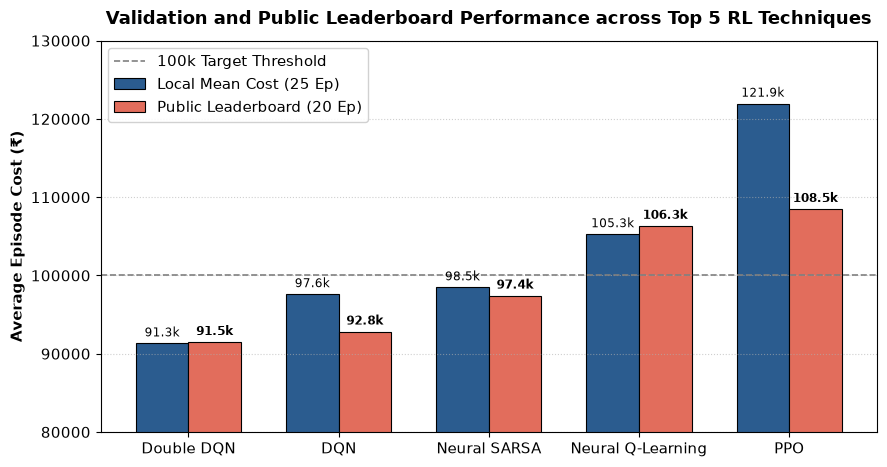

In [6]:
# Set consistent styling
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

# ====================================================================
# PLOT 1: Local Mean vs. Public Leaderboard Cost (Top 5 Techniques)
# ====================================================================
techniques = [
    'Double DQN',
    'DQN',
    'Neural SARSA',
    'Neural Q-Learning',
    'PPO',
]
local_costs = [91315.00, 97601.40, 98475.50, 105263.40, 121948.30]
public_costs = [91499.25, 92836.12, 97430.62, 106344.00, 108498.12]

x = np.arange(len(techniques))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.8))
rects1 = ax.bar(
    x - width / 2,
    local_costs,
    width,
    label='Local Mean Cost (25 Ep)',
    color='#2b5c8f',
    edgecolor='black',
    linewidth=0.8,
)
rects2 = ax.bar(
    x + width / 2,
    public_costs,
    width,
    label='Public Leaderboard (20 Ep)',
    color='#e26d5c',
    edgecolor='black',
    linewidth=0.8,
)

# Reference benchmark line at 100k
ax.axhline(
    100000,
    color='grey',
    linestyle='--',
    linewidth=1.2,
    label='100k Target Threshold',
)

ax.set_ylabel('Average Episode Cost (₹)', fontweight='bold')
ax.set_title(
    'Validation and Public Leaderboard Performance across Top 5 RL Techniques',
    fontweight='bold',
    pad=12,
)
ax.set_xticks(x)
ax.set_xticklabels(techniques, fontweight='medium')
ax.set_ylim(80000, 130000)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Add exact value labels on top of bars
for rect in rects1:
  height = rect.get_height()
  ax.annotate(
      f'{height/1000:.1f}k',
      xy=(rect.get_x() + rect.get_width() / 2, height),
      xytext=(0, 3),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
  )

for rect in rects2:
  height = rect.get_height()
  ax.annotate(
      f'{height/1000:.1f}k',
      xy=(rect.get_x() + rect.get_width() / 2, height),
      xytext=(0, 3),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
      fontweight='bold',
  )

plt.tight_layout()
plt.savefig('plot1_benchmark_comparison.png', dpi=300)
plt.show()


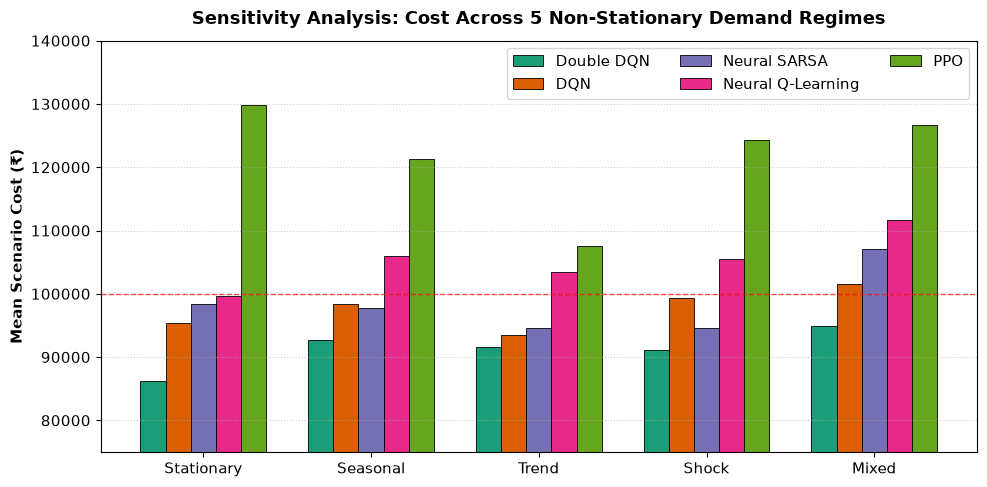

In [7]:
# ====================================================================
# PLOT 2: Cost Breakdown Across 5 Non-Stationary Scenario Regimes
# ====================================================================
scenarios = ['Stationary', 'Seasonal', 'Trend', 'Shock', 'Mixed']
scenario_data = {
    'Double DQN': [86167.0, 92633.0, 91618.0, 91196.0, 94961.0],
    'DQN': [95391.5, 98347.0, 93410.0, 99325.5, 101533.0],
    'Neural SARSA': [98466.0, 97746.0, 94547.0, 94576.5, 107042.0],
    'Neural Q-Learning': [99593.5, 106006.0, 103476.0, 105515.5, 111726.0],
    'PPO': [129878.5, 121286.0, 107588.0, 124241.0, 126748.0],
}

x_scen = np.arange(len(scenarios))
w = 0.15
colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']

fig, ax2 = plt.subplots(figsize=(10, 5))

for i, (name, values) in enumerate(scenario_data.items()):
  pos = x_scen + (i - 2) * w
  ax2.bar(
      pos,
      values,
      w,
      label=name,
      color=colors[i],
      edgecolor='black',
      linewidth=0.6,
  )

ax2.set_ylabel('Mean Scenario Cost (₹)', fontweight='bold')
ax2.set_title(
    'Sensitivity Analysis: Cost Across 5 Non-Stationary Demand Regimes',
    fontweight='bold',
    pad=12,
)
ax2.set_xticks(x_scen)
ax2.set_xticklabels(scenarios, fontweight='medium')
ax2.set_ylim(75000, 140000)
ax2.axhline(100000, color='red', linestyle='--', linewidth=1.0, alpha=0.7)
ax2.legend(ncol=3, loc='upper right', frameon=True)
ax2.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('plot2_scenario_breakdown.png', dpi=300)
plt.show()

## 19. Submission checks

For every policy file:
```bash
python policy_validation_tests.py tabular_q_learning/policy.py 
python policy_validation_tests.py tabular_sarsa/policy.py 
python policy_validation_tests.py td_lambda/policy.py
python policy_validation_tests.py neural_q_learning/policy.py
python policy_validation_tests.py neural_sarsa/policy.py
python policy_validation_tests.py reinforce/policy.py
python policy_validation_tests.py a2c/policy.py 
python policy_validation_tests.py a3c/policy.py
python policy_validation_tests.py ppo/policy.py 
python policy_validation_tests.py deep_q_network/policy.py 
python policy_validation_tests.py double_dqn/policy.py
```